# Základy měření s termokamerou

Na tomto cvičení budeme používat kamery [Tau2](https://www.flir.com/products/tau-2/) od firmy FLIR. 

Tau2 je schopno několika módů snímání. V prvním módu snímá veličinu, která je lineární s radiometrickým fluxem.
V druhém módu (který budeme používat my) snímá veličinu lineární s teplotou scény. Výhoda druhého modelu je taková, že kompenzuje vliv teploty jádra na naměřenou teplotu scény.

Kamery snímají infračervené záření o vlnové délce ~7.5 - ~13.5 μm, jinými slovy měří [radiometrický flux](https://en.wikipedia.org/wiki/Radiant_flux). Vztah mezi fluxem a zdánlivou povrchovou teplotou je popsaný ve funkcích `flux_to_temp` a `temp_to_flux`. Pro jednoduchost teplotu měříme v Kelvinech.

Parametry `R B F O` jsou fitnuté při kalibraci kamery, pro nás nemají žádný význam (pro zájemce [Planck's law](https://en.wikipedia.org/wiki/Planck%27s_law)).

Popíšeme model, který kamera používá, aby z celkového naměřeného fluxu (scene flux) vyrobila povrchovou teplotu měřeného objektu.
Kamera snímá celkový flux scény, ten se skládá z:
- flux vyzářený měřeným objektem
- flux vyzářený dalšími objekty ve scéně

Měřený flux je dále ovlivněn atmosférou, která část pohltí a část sama vyzáří.
V poslední řadě se aplikuje vliv filtru, který část záření pohltí a část odrazí.
Celkový flux, který naměří kamera nazýváme scene flux.

Kamera provádí postprocessing, aby ze scene flux vyrobila flux měřeného objektu.
Model si vyrobíme na tomto cvičení.

Platí:
$$
1 = \tau + r + \varepsilon,
$$
kde $\tau$ je transmisivita (propustnost), $r$ je reflexivita (odrazivost) a $\varepsilon$ je emisivita. 

Známé hodnoty emisivity (7.5 - 13.5 μm):
https://www.engineeringtoolbox.com/emissivity-coefficients-d_447.html

Známé hodnoty transmisivity (7.5 - 13.5 μm):
- germániové sklo: 0.4
- germániové sklo s antireflexním coatingem: 0.95

![Radiometrický model](./images/radiometric_model.png)

## Měření propustnosti fólie (2b)

In [12]:
import numpy as np
import cv2 as cv
from matplotlib import pyplot as plt
import improutils

In [2]:
def flux_to_temp(val):
    return (
        sensor_params.B / np.log(sensor_params.R / 
        (val - sensor_params.O) + sensor_params.F)
    )


def temp_to_flux(val):
    return (
        sensor_params.R / 
        (np.exp(sensor_params.B / val) - sensor_params.F) + sensor_params.O
    )


def tlin_to_temp(val):
    return val * 0.04


def atmospheric_transmissivity(atm_temp_C, humidity, distance_m):
    K1 = 1.5587e+0
    K2 = 6.9390e-2
    K3 = -2.7816e-4
    K4 = 6.8455e-7

    # alpha = 0.01262
    alpha = 0
    beta = -0.00667

    # NOTE: Tayloruv polynom 3. radu
    exponent = (
        K1 + K2 * atm_temp_C + 
        K3 * atm_temp_C**2 + K4 * atm_temp_C**3
    )

    sqrt_H2O = np.sqrt(humidity * np.exp(exponent))
    sqrt_distance_m = np.sqrt(distance_m)
    return np.exp(sqrt_distance_m * (alpha + beta * sqrt_H2O))

In [49]:
# Pozor, data získaná z kamery jsou 16bitová
imgs = {
    'TauPlayer/flux_no_filter.png',
    'TauPlayer/flux_filter.png'
}

images = [cv.imread(img, cv.IMREAD_ANYDEPTH) for img in imgs]
def to_temp_img(img):
    img = img.copy().astype(np.float)
    for row in range(len(img)):
        for col in range(len(img[row])):
            img[row][col] = tlin_to_temp(img[row][col]) - 272.15
    return img
images_temp = [to_temp_img(img) for img in images]
print(images_temp[0], images_temp[1])

`np.float` is a deprecated alias for the builtin `float`. To silence this warning, use `float` by itself. Doing this will not modify any behavior and is safe. If you specifically wanted the numpy scalar type, use `np.float64` here.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations


[[      21.13       21.13       21.13 ...       24.89       24.89       24.89]
 [      21.13       21.13       21.13 ...       24.89       24.85       24.85]
 [      21.17       21.09       21.17 ...       24.89       24.85       24.81]
 ...
 [      20.41       20.37       20.33 ...       22.13       22.13       22.13]
 [      20.45       20.33       20.33 ...       22.05       22.13       22.13]
 [      20.37       20.37       20.33 ...       22.01       22.09       22.13]] [[      24.89       24.85       24.89 ...       25.57       25.57       25.57]
 [      24.81       24.93       24.77 ...       25.57       25.57       25.57]
 [      24.89       24.89       24.85 ...       25.61       25.57       25.57]
 ...
 [      24.41       24.41       24.41 ...       25.17       25.17       25.17]
 [      24.41       24.29       24.41 ...       25.13       25.13       25.21]
 [      24.37       24.41       24.41 ...       25.17       25.17       25.17]]


## Zobrazte získaná data ve stupních C

In [50]:
print(images_temp[0], images_temp[1])

[[      21.13       21.13       21.13 ...       24.89       24.89       24.89]
 [      21.13       21.13       21.13 ...       24.89       24.85       24.85]
 [      21.17       21.09       21.17 ...       24.89       24.85       24.81]
 ...
 [      20.41       20.37       20.33 ...       22.13       22.13       22.13]
 [      20.45       20.33       20.33 ...       22.05       22.13       22.13]
 [      20.37       20.37       20.33 ...       22.01       22.09       22.13]] [[      24.89       24.85       24.89 ...       25.57       25.57       25.57]
 [      24.81       24.93       24.77 ...       25.57       25.57       25.57]
 [      24.89       24.89       24.85 ...       25.61       25.57       25.57]
 ...
 [      24.41       24.41       24.41 ...       25.17       25.17       25.17]
 [      24.41       24.29       24.41 ...       25.13       25.13       25.21]
 [      24.37       24.41       24.41 ...       25.17       25.17       25.17]]


## Vykreslete graf závislosti transmisivity atmosféry na vzdálenosti a na vlhkosti

Použijte funkci atmospheric_transmisivity.

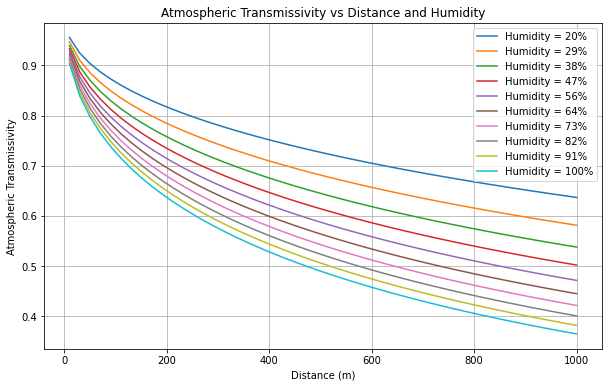

In [51]:
def plot_transmissivity():
    atm_temp_C = 25  
    
    distances = np.linspace(10, 1000, 50) 
    humidities = np.linspace(0.2, 1.0, 10) 

    plt.figure(figsize=(10, 6))

    for humidity in humidities:
        transmissivities = [atmospheric_transmissivity(atm_temp_C, humidity, d) for d in distances]
        plt.plot(distances, transmissivities, label=f'Humidity = {humidity*100:.0f}%')

    plt.xlabel('Distance (m)')
    plt.ylabel('Atmospheric Transmissivity')
    plt.title('Atmospheric Transmissivity vs Distance and Humidity')
    plt.legend()
    plt.grid(True)
#     plt.xscale('log') 
#     plt.yscale('log') 
    plt.show()

plot_transmissivity()

## Změřte propustnost folie

Naimplementujte funkce, které budou sloužit na výpočet `obj_flux` a `scene_flux`.
Dále změřte propustnost filtru na objektivu a vytvořte model, který bude kompenzovat vliv filtru na výsledných snímcích.

In [58]:
class SensorParameters:
    R = 395654
    B = 1428
    F = 1
    O = 156

sensor_params = SensorParameters()

class RadiometricModel:
    obj_trans = 0  # zanedbáváme
    atm_reflex = 0  # zanedbáváme
    win_emis = 0  # zanedbáváme

    def __init__(self, *, obj_emis=0.95, bkg_temp=293.15,
            atm_temp=293.15, atm_trans=0.95, 
            win_temp=293.15, win_trans=0.95):
        # object
        self.obj_emis = obj_emis
        self.obj_reflex = 1 - obj_emis

        # background
        self.bkg_temp = bkg_temp

        # atmosphere
        self.atm_temp = atm_temp  
        self.atm_trans = atm_trans
        self.atm_emis = 1 - atm_trans

        # window
        self.win_temp = win_temp
        self.win_trans = win_trans
        self.win_reflex = 1 - win_trans
     
#     f3 = fsin
    def get_fobj(self, f3):
        f2 = (f3 - self.win_reflex * temp_to_flux(self.win_temp)) / (1-self.win_trans)
        f1 = (f2-((1-self.atm_trans) * temp_to_flux(self.atm_temp))) / self.atm_trans
        fobj = (f1-((1-self.obj_emis) * temp_to_flux(self.bkg_temp))) / self.obj_emis
        return fobj
    
    def get_f3(self, fobj):
        f1 = self.obj_emis * fobj + (1-self.obj_emis)*temp_to_flux(self.bkg_temp)
        f2 = (1-self.atm_trans) * temp_to_flux(self.atm_temp) + self.atm_trans * f1
        f3 = self.win_reflex * temp_to_flux(self.win_temp) + (1 - self.win_trans) * f2
        return f3
        

In [59]:
def obj_flux_to_scene_flux(model: RadiometricModel, obj_flux):
    return model.get_f3(obj_flux)

def scene_flux_to_obj_flux(model: RadiometricModel, scene_flux):
    return model.get_fobj(scene_flux)

In [60]:
def img_to_scene_flux(img):
    model = RadiometricModel()
    img = img.copy().astype(np.float)
    for row in range(len(img)):
        for col in range(len(img[row])):
            img[row][col] = tlin_to_temp(img[row][col])
            img[row][col] = obj_flux_to_scene_flux(model, img[row][col])
    return img
images_scene_flux = [img_to_scene_flux(img) for img in images]

filter_trans = np.sum(images_scene_flux[1]) / np.sum(images_scene_flux[0])
# obj_flux_to_scene_flux()

`np.float` is a deprecated alias for the builtin `float`. To silence this warning, use `float` by itself. Doing this will not modify any behavior and is safe. If you specifically wanted the numpy scalar type, use `np.float64` here.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations


In [61]:
print(filter_trans)

0.9997936263389916


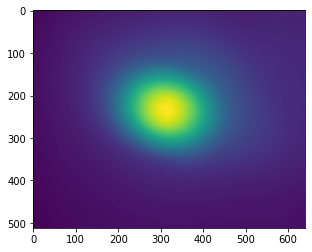

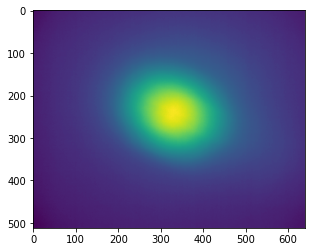

In [62]:
plt.imshow(images_scene_flux[0])
plt.show()
plt.imshow(images_scene_flux[1])
plt.show()

In [63]:
ratio_matrix = images_scene_flux[1]/images_scene_flux[0]

In [64]:
ratio_matrix = np.mean(ratio_matrix[200:400,200:400])

In [65]:
print(ratio_matrix)

0.9975639752581931


In [47]:
print(images_scene_flux[0])

[[     182.54      182.54      182.54 ...      182.71      182.71      182.71]
 [     182.54      182.54      182.54 ...      182.71      182.71      182.71]
 [     182.55      182.54      182.55 ...      182.71      182.71      182.71]
 ...
 [     182.51      182.51      182.51 ...      182.59      182.59      182.59]
 [     182.51      182.51      182.51 ...      182.59      182.59      182.59]
 [     182.51      182.51      182.51 ...      182.58      182.59      182.59]]


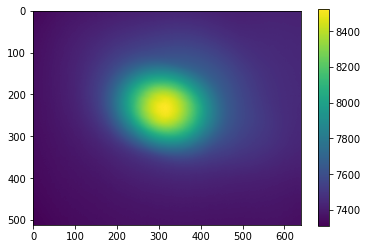

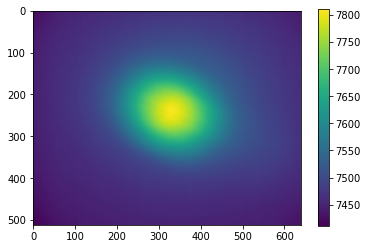

In [67]:
plt.imshow(images[0])
plt.colorbar()
plt.show()
plt.imshow(images[1])
plt.colorbar()
plt.show()